# Classify Song genre from audio data

## Importing libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

import joblib
from joblib import dump

In [2]:
train_pca = pd.read_csv('train_pca.csv',header= None)
test_pca = pd.read_csv('test_pca.csv',header= None)
train_labels = pd.read_csv('y_train.csv',header= None)
test_labels = pd.read_csv('y_test.csv',header= None)

In [3]:
# Reshape the target variable using ravel()
train_labels = np.ravel(train_labels)
test_labels = np.ravel(test_labels)

## Model Building

In [4]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['Hip-Hop', 'Rock']); 
    ax.yaxis.set_ticklabels(['Hip-Hop', 'Rock'])

Decision Tree: Classfication report
              precision    recall  f1-score   support

     Hip-Hop       0.82      0.77      0.79       230
        Rock       0.78      0.82      0.80       225

    accuracy                           0.80       455
   macro avg       0.80      0.80      0.80       455
weighted avg       0.80      0.80      0.80       455

Accuracy: 0.7956043956043956


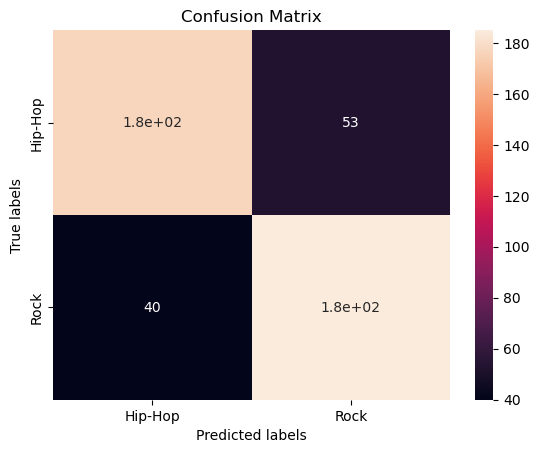

In [5]:
## Decision Trees

# Create a Decision Tree classifier
decision_tree = DecisionTreeClassifier(random_state=10)

# Train the model
decision_tree.fit(train_pca, train_labels)

# Make predictions on the testing set
y_pred = decision_tree.predict(test_pca)

# Calculate classification report
cr = classification_report(test_labels, y_pred)

# Plot confusion matrix
plot = plot_confusion_matrix(test_labels,y_pred)

# Calculate accuracy
accuracy = accuracy_score(test_labels, y_pred)

# Print the accuracy of each model
print(f'Decision Tree: Classfication report')
print(f'{cr}')
print('Accuracy:', accuracy)



Logistic Regression: Classfication report
              precision    recall  f1-score   support

     Hip-Hop       0.84      0.80      0.82       230
        Rock       0.81      0.85      0.83       225

    accuracy                           0.82       455
   macro avg       0.82      0.82      0.82       455
weighted avg       0.83      0.82      0.82       455

Accuracy: 0.8241758241758241


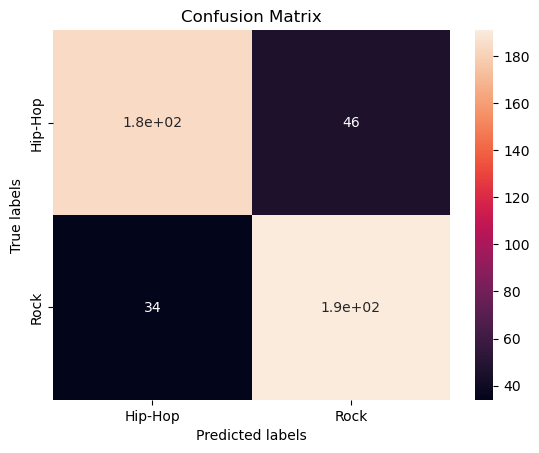

In [6]:
## Logistic Regression

# Create a Logistic Regression classifier
logistic_regression = LogisticRegression(random_state=10, max_iter=1000)

# Train the model
logistic_regression.fit(train_pca, train_labels)

# Make predictions on the testing set
y_pred = logistic_regression.predict(test_pca)

# Calculate classification report
cr = classification_report(test_labels, y_pred)

# Plot confusion matrix
plot = plot_confusion_matrix(test_labels,y_pred)

# Calculate accuracy
accuracy = accuracy_score(test_labels, y_pred)

# Print the accuracy of each model
print(f'Logistic Regression: Classfication report')
print(f'{cr}')
print('Accuracy:', accuracy)


SVM: Classfication report
              precision    recall  f1-score   support

     Hip-Hop       0.88      0.83      0.86       230
        Rock       0.84      0.88      0.86       225

    accuracy                           0.86       455
   macro avg       0.86      0.86      0.86       455
weighted avg       0.86      0.86      0.86       455

Accuracy: 0.8593406593406593


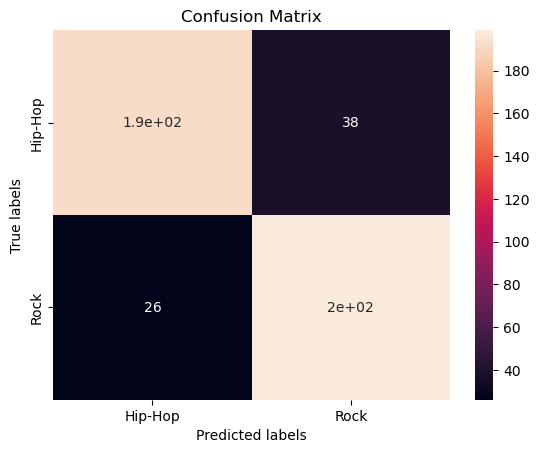

In [7]:
## Support Vector machine

# Create a Support Vector Machine classifier
support_vector_machine = SVC(random_state=10)

# Train the model
support_vector_machine.fit(train_pca, train_labels)

# Make predictions on the testing set
y_pred = support_vector_machine.predict(test_pca)

# Calculate classification report
cr = classification_report(test_labels, y_pred)

# Plot confusion matrix
plot = plot_confusion_matrix(test_labels,y_pred)

# Calculate accuracy
accuracy = accuracy_score(test_labels, y_pred)

# Print the accuracy of each model
print(f'SVM: Classfication report')
print(f'{cr}')
print('Accuracy:', accuracy)


By observing precision,recall, f1-score and confusion matrix we can say SVM outperforms than remaining algorithms. Lets perform hyperparameter tuning and conclude the best model for further deployment use.

## Hyperparameter Tuning and Model evaluation

By using cross-validation and hyperparameter tuning, we can ensure that the model performs well on unseen data, avoids overfitting or underfitting, and achieves its highest potential accuracy and generalization ability.

In [8]:
methods=[]
acc=[]
area_under_curve=[]

Accuracy: 0.7978021978021979
Confusion Matrix:
AUC: 0.875256038647343


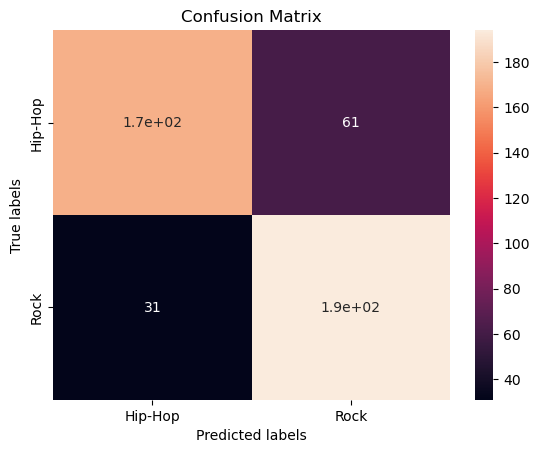

In [9]:
## Decision trees

# define the parameter grid
param_grid = {
            'criterion': ['gini', 'entropy'],
            'max_depth': [i for i in range(5,21,1)],
            'min_samples_leaf' :  [i for i in range(20,500,20)]
        }

#  define the classifier
tree = DecisionTreeClassifier(random_state=10)

# setup the grid search
tree_cv = GridSearchCV(tree, param_grid, scoring='roc_auc', cv = 10)

# Fit the grid search to the training data
tree_cv.fit(train_pca, train_labels)

# Get the best model and its predicted labels and probabilities
best_model = tree_cv.best_estimator_
y_pred = best_model.predict(test_pca)
y_pred_proba = best_model.predict_proba(test_pca)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(test_labels, y_pred)

# Calculate confusion matrix
cm = plot_confusion_matrix(test_labels,y_pred)

# Calculate AUC
auc = roc_auc_score(test_labels, y_pred_proba)

# Print the results
print('Accuracy:', accuracy)
print('Confusion Matrix:')
print('AUC:', auc)

# Appending accuracy and auc to lists
methods.append('Decision Tree')
acc.append(accuracy)
area_under_curve.append(auc)

Accuracy: 0.8241758241758241
Confusion Matrix:
None
AUC: 0.8962898550724638


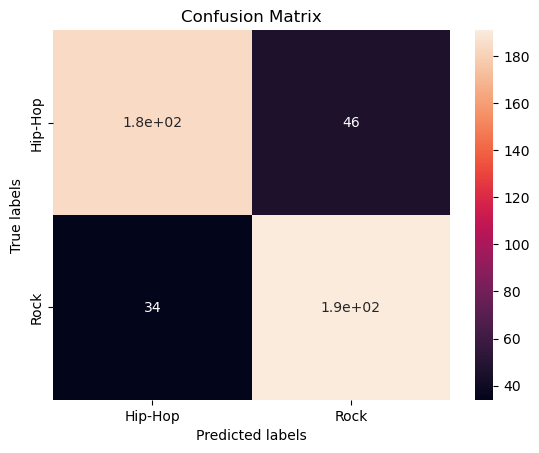

In [10]:
## Logistic regression

# define the parameter grid
param_grid = param_grid = {
            'C': [0.1, 1, 10,100,1000],
            'penalty' : ['l2']
        }

#  define the classifier
lr = LogisticRegression(random_state=10)

# setup the grid search
lr_cv = GridSearchCV(lr, param_grid, scoring='roc_auc', cv = 10)

# Fit the grid search to the training data
lr_cv.fit(train_pca, train_labels)

# Get the best model and its predicted labels and probabilities
best_model = lr_cv.best_estimator_
y_pred = best_model.predict(test_pca)
y_pred_proba = best_model.predict_proba(test_pca)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(test_labels, y_pred)

# Calculate confusion matrix
cm = plot_confusion_matrix(test_labels,y_pred)

# Calculate AUC
auc = roc_auc_score(test_labels, y_pred_proba)

# Print the results
print('Accuracy:', accuracy)
print('Confusion Matrix:')
print(cm)
print('AUC:', auc)

# Appending accuracy and auc to lists
methods.append('Logistic Regression')
acc.append(accuracy)
area_under_curve.append(auc)

Accuracy: 0.8505494505494505
Confusion Matrix:
None
AUC: 0.9208888888888889


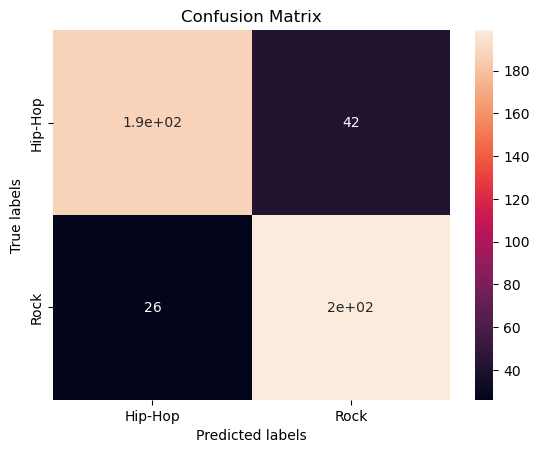

In [11]:
## SVM

# define the parameter grid
param_grid = param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf','sigmoid','poly'],
            'gamma': [1, 0.1, 0.01]
        }

#  define the classifier
svm = SVC(random_state=10,probability=True)

# setup the grid search
svm_cv = GridSearchCV(svm, param_grid, scoring='roc_auc', cv = 10)

# Fit the grid search to the training data
svm_cv.fit(train_pca, train_labels)

# Get the best model and its predicted labels and probabilities
best_model = svm_cv.best_estimator_
y_pred = best_model.predict(test_pca)
y_pred_proba = best_model.predict_proba(test_pca)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(test_labels, y_pred)

# Calculate confusion matrix
cm = plot_confusion_matrix(test_labels,y_pred)

# Calculate AUC
auc = roc_auc_score(test_labels, y_pred_proba)

# Print the results
print('Accuracy:', accuracy)
print('Confusion Matrix:')
print(cm)
print('AUC:', auc)

# Appending accuracy and auc to lists
methods.append('SVM')
acc.append(accuracy)
area_under_curve.append(auc)

Finally after tuning the hyperparameters and performing Cross-validation we observe that the Area under the ROC curve is higher for SVM and obtained 85% accuracy.
The confusion matrix for SVM looks good in predicting the classes as compared to other algorithms predictions. 

## Saving the model

In [15]:
# Save the best estimator model
joblib.dump(svm_cv.best_estimator_, 'best_model.pkl')

['best_model.pkl']